<a href="https://colab.research.google.com/github/thanhthuy280501/Data-Visualization/blob/main/Copy_of_HW6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns

##Q3
Please follow the instructions below and inspect the outputs before you proceed. You can always check this original final to compare your results in your own copy.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
#You have to make sure that you were able to write the file to a csv while your were working in R
house=pd.read_csv('/content/drive/MyDrive/DATA/house_prices.csv')
house.head()

,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
0,1,1976-01-01,Alabama,6.7,37.138285,0.040405
1,2,1976-02-01,Alabama,6.7,37.756437,0.051806
2,3,1976-03-01,Alabama,6.6,38.276319,0.059302
3,4,1976-04-01,Alabama,6.5,38.596135,0.059585
4,5,1976-05-01,Alabama,6.4,38.740517,0.055723


a) For the states below, please select the rows from the house dataframe, and consider converting the date column to date data type as it may be coming in string format. Then use the head function to preview your new dataframe.

In [7]:
states = ['Michigan', 'California', 'Texas', 'Indiana']
house_filtered = house[house['state'].isin(states)].copy()
house_filtered['date'] = pd.to_datetime(house_filtered['date'])
display(house_filtered.head())

,Unnamed: 0,date,state,unemploy_perc,house_price_index,house_price_perc
2016,2017,1976-01-01,California,9.1,17.908764,0.139067
2017,2018,1976-02-01,California,9.1,18.117587,0.148485
2018,2019,1976-03-01,California,9.0,18.379530,0.151243
2019,2020,1976-04-01,California,9.0,18.673067,0.147308
2020,2021,1976-05-01,California,8.9,18.899995,0.143167


b) Use the FacetGrid from seaborn to create line plots to represent house_price_index for each state. Please make the line color red, set ticks on x axis for years ['1980', '2000', '2020'], which you may have to convert date type again, put those years as labels, and set the titles for each small plot to their state names. In addition, set the y label to 'house price index' and remove the x label since it's obvious that these are years.

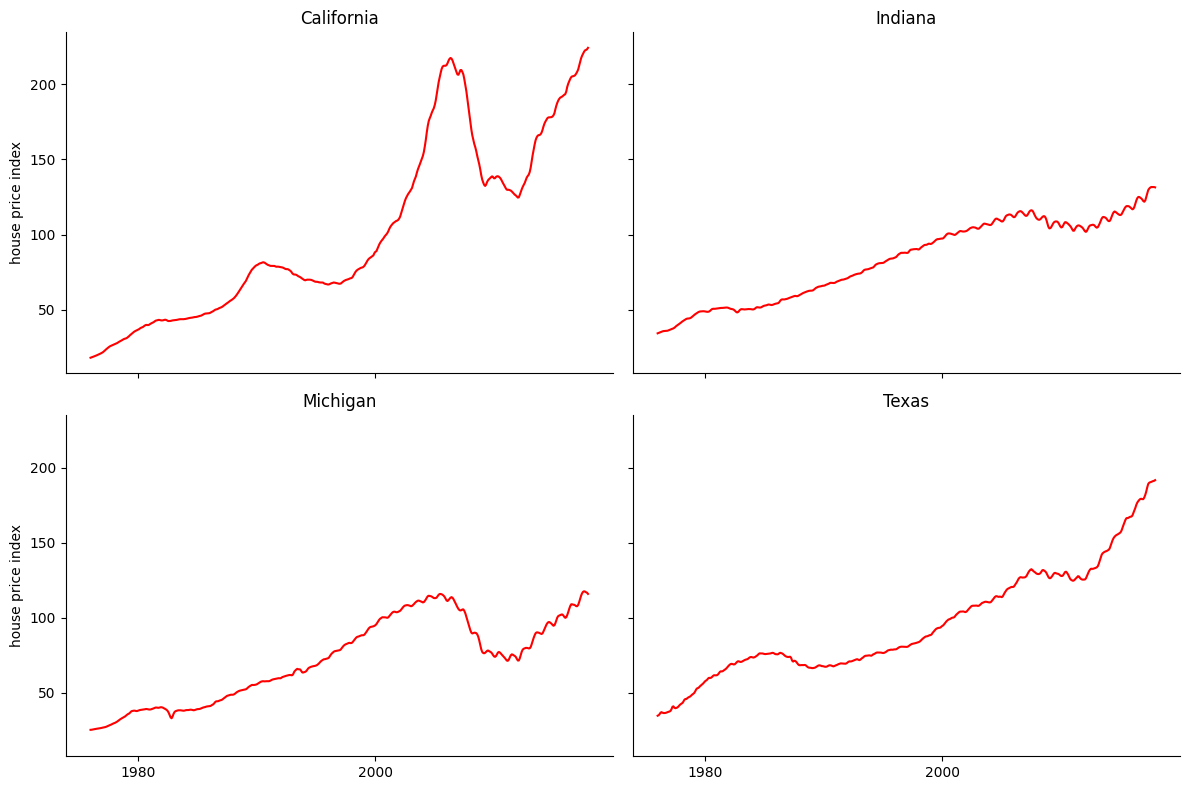

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(house_filtered, col='state', col_wrap=2, height=4, aspect=1.5)
g.map(sns.lineplot, 'date', 'house_price_index', color='red')

def format_x_ticks(dates, years_to_show=['1980', '2000', '2020']):
    tick_positions = []
    tick_labels = []
    for year_str in years_to_show:
        year_start = pd.to_datetime(year_str + '-01-01')
        if year_start >= dates.min() and year_start <= dates.max():
            tick_positions.append(year_start)
            tick_labels.append(year_str)
    return tick_positions, tick_labels

for ax in g.axes.flat:
    state_name = ax.get_title().split('=')[-1].strip()
    ax.set_title(state_name) # Set title to state name
    ax.set_ylabel('house price index')
    ax.set_xlabel('') # Remove x-label

    # Set specific x-axis ticks and labels
    tick_pos, tick_labels = format_x_ticks(house_filtered['date'])
    ax.set_xticks(tick_pos)
    ax.set_xticklabels(tick_labels)

plt.tight_layout()
plt.show()

c) Draw a lineplot for 'house price perc', but color them based on the 'state' name which will have four lines in a single plot. Set a legend which will be at the bottom of your graph and have them horizantally positioned next to eachother. Again, set the y label to house_price_perc and remove the x label since it's obvious. (Note that my y label is still showing index. Please ignore that.)

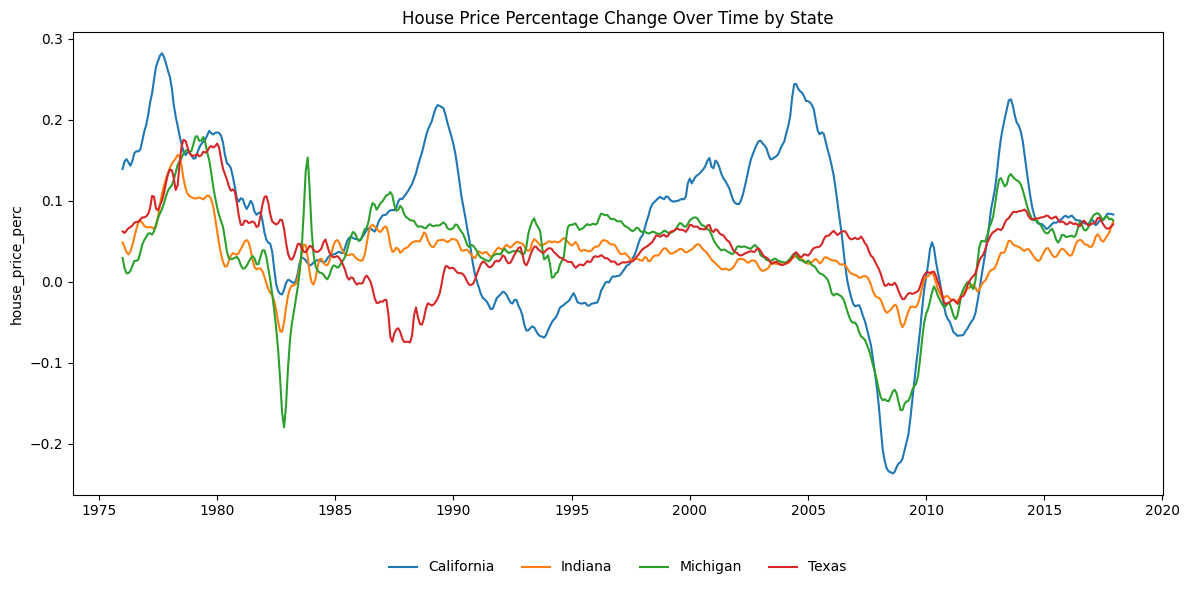

In [9]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=house_filtered, x='date', y='house_price_perc', hue='state')
plt.xlabel('') # Remove x-label
plt.ylabel('house_price_perc') # Set y-label
plt.title('House Price Percentage Change Over Time by State')
plt.legend(loc='lower center', bbox_to_anchor=(0.5, -0.2), ncol=len(house_filtered['state'].unique()), frameon=False)
plt.tight_layout()
plt.show()

##Q4
Please work on your 4th question below. Please feel free to add new code cells.

In [10]:
#Your code goes here.
world_cup = pd.read_csv('/content/drive/MyDrive/DATA/WorldCupMatches.csv')
world_cup.head()


,Year,Datetime,Stage,Stadium,City,Home Team Name,Home Team Goals,Away Team Goals,Away Team Name,Win conditions,Attendance,Half-time Home Goals,Half-time Away Goals,Referee,Assistant 1,Assistant 2,RoundID,MatchID,Home Team Initials,Away Team Initials
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,,4444.0,3,0,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,,18346.0,2,0,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,,24059.0,2,0,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,,2549.0,1,0,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,,23409.0,0,0,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA


In [11]:
# Group by 'Home Team Initials' and 'Away Team Initials'
# Calculate 'weight' (number of matches) and 'HomeGoalTotal' (sum of home goals)
team_pairs = world_cup.groupby(['Home Team Initials', 'Away Team Initials']).agg(
    weight=('Year', 'count'), # Count any column to get the number of matches
    HomeGoalTotal=('Home Team Goals', 'sum')
).reset_index()

team_pairs.head()

,Home Team Initials,Away Team Initials,weight,HomeGoalTotal
0,ALG,AUT,1,0
1,ALG,CHI,1,3
2,ALG,ESP,1,0
3,ALG,NIR,1,1
4,ALG,RUS,1,1


In [12]:
home_team_total_goals = world_cup.groupby('Home Team Initials')['Home Team Goals'].sum().reset_index()
home_team_total_goals.rename(columns={'Home Team Goals': 'HomeGoalTotal'}, inplace=True)
display(home_team_total_goals.head())

,Home Team Initials,HomeGoalTotal
0,ALG,5
1,ANG,0
2,ARG,111
3,AUS,7
4,AUT,31


In [13]:
team_pairs[['Home Team Initials', 'Away Team Initials', 'weight', 'HomeGoalTotal']].to_csv('team_pairs.csv', index=False)
print("team_pairs.csv saved successfully!")

team_pairs.csv saved successfully!


In [14]:
import pandas as pd

team_pairs_df = pd.read_csv('team_pairs.csv')
display(team_pairs_df.head())

,Home Team Initials,Away Team Initials,weight,HomeGoalTotal
0,ALG,AUT,1,0
1,ALG,CHI,1,3
2,ALG,ESP,1,0
3,ALG,NIR,1,1
4,ALG,RUS,1,1
